# Passing Data instances as parameters

Loaders are plain Python objects. They can be passed as constructor arguments
to other loaders, stored in lists, swapped at runtime. This page shows what
that means for hashing, cache invalidation, and the dependency graph.

## The pattern

Consider a loader that computes the pixel-wise correlation between two
geospatial variables. The natural signature is:

```python
# loaders/correlation.py
from dataclasses import dataclass

import numpy as np
from pygeodata.api import load
from pygeodata.data import Data
from pygeodata.drivers.rioxarray import RioXArrayDriver
from pygeodata.types import SpatialSpec


@dataclass
class FeatureCorrelationLoader(Data):
    """
    Pearson correlation between two spatial variables at each pixel over time.

    Both ``feature`` and ``variable`` are Data instances — they are computed
    (or loaded from cache) at runtime and their hashes are part of this
    loader's cache key.
    """

    feature: Data = None
    variable: Data = None

    ext = 'tif'
    driver = RioXArrayDriver()

    def _process(self, spec: SpatialSpec) -> None:
        x = load(self.feature, spec)
        y = load(self.variable, spec)
        corr = np.corrcoef(x.values.ravel(), y.values.ravel())[0, 1]
        import xarray as xr
        out = xr.full_like(x, fill_value=float(corr))
        out.rio.to_raster(self.get_processed_path(spec))
```

`feature` and `variable` have type `Data`, not `ElevationLoader` or any
specific subclass. Any loader can be wired in.

In [1]:
import sys, os

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from loaders.dem import ElevationLoader, SlopeLoader
from loaders.climate import LSTLoader, NDVILoader
from loaders.correlation import FeatureCorrelationLoader

## How the instance hash is computed

When pygeodata computes `FeatureCorrelationLoader.get_instance_hash()`, it
serialises the `params` dict before hashing:

```python
state = {
    'dependency_tree_hash': cls.get_dependency_tree_hash(),
    'params': {k: format_json(v) for k, v in self.get_params().items()},
}
```

`format_json` recurses into `Data` instances and replaces them with their
`instance_hash`. So the effective params dict for

```python
FeatureCorrelationLoader(
    feature=ElevationLoader(src='data/srtm_30m.tif'),
    variable=LSTLoader(year=2020),
)
```

looks like:

```json
{
    "feature":   {"class_name": "ElevationLoader", "instance_hash": "a3f8…"},
    "variable":  {"class_name": "LSTLoader",       "instance_hash": "c72d…"}
}
```

Swapping either parameter produces a different instance hash, a different
state hash, and a different output directory.

In [2]:
loader_a = FeatureCorrelationLoader(
    feature=ElevationLoader(),
    variable=LSTLoader(year=2020),
)
loader_b = FeatureCorrelationLoader(
    feature=ElevationLoader(),
    variable=LSTLoader(year=2021),
)

print('loader_a instance hash:', loader_a.get_instance_hash())
print('loader_b instance hash:', loader_b.get_instance_hash())
print('hashes differ:', loader_a.get_instance_hash() != loader_b.get_instance_hash())

loader_a instance hash: 8bc8e091ecec52bd25b2254be843d7ab8fe2fe539072d057e6f7463da753eb9f
loader_b instance hash: 906de457dd77e25c30e227ba8961a1222a5e9f614f9118b3c2affeb0eda073ed
hashes differ: True


## Changing a dependency invalidates downstream caches

Suppose `ElevationLoader` is edited — say, the reprojection resampling
algorithm is changed from `bilinear` to `nearest`:

```python
@dataclass
class ElevationLoader(Data):
    src: str = 'data/srtm_30m.tif'

    @property
    def processor(self):
        return Reprojector(src_path=self.src, resampling=Resampling.nearest)  # changed
```

The hash chain unwinds from the bottom:

1. `calculate_cls_source_hash(ElevationLoader)` → new hash.
2. `ElevationLoader.get_dependency_tree_hash()` → new hash.
3. `ElevationLoader.get_instance_hash()` → new hash.
4. `FeatureCorrelationLoader.get_dependency_tree_hash()` includes the source
   hash of every reachable class, including `ElevationLoader` → new hash.
5. `FeatureCorrelationLoader.get_instance_hash()` → new hash (dep_tree_hash
   changed, and the `feature` param's `instance_hash` changed).
6. `FeatureCorrelationLoader.get_state_hash(spec)` → new hash.
7. Cache miss for `FeatureCorrelationLoader`. Recompute.

`ElevationLoader` also recomputes. Any other loader that lists
`ElevationLoader` as a call dependency — detected by AST analysis of its
class body — will also have a stale `dependency_tree_hash` and will recompute.

## Running multiple configurations simultaneously

Because the state hash incorporates the full parameter tree, you can process
multiple configurations in a single script without them interfering:

```python
import pygeodata as pgd

pgd.get_config().update(path_cache='data_processed')
spec = pgd.SpatialSpec.from_raster_file('reference.tif')

configs = [
    FeatureCorrelationLoader(feature=ElevationLoader(), variable=LSTLoader(year=2020)),
    FeatureCorrelationLoader(feature=ElevationLoader(), variable=LSTLoader(year=2021)),
    FeatureCorrelationLoader(feature=NDVILoader(),      variable=LSTLoader(year=2020)),
]

for loader in configs:
    pgd.process(loader, spec)
```

Each produces a separate directory under `data_processed/`. Re-running the
script is a no-op for whichever configurations are still valid.

## The class dependency graph

The class-level graph shows which *classes* can depend on which other classes,
as discovered by static AST analysis.

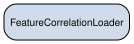

In [3]:
import os, tempfile
from pygeodata.graphs import plot_class_dependency_graph
from IPython.display import SVG, display

graph_data = FeatureCorrelationLoader.get_dependency_graph()

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, 'graph_feature_correlation.svg')
    plot_class_dependency_graph(
        cls_name='FeatureCorrelationLoader',
        graph_data=graph_data,
        path=path,
    )
    display(SVG(path))

## The runtime execution graph

The class-level graph shows which *classes* can depend on which other classes.
At runtime, after a `process()` call that involves loaders passed as
parameters, pygeodata also builds a per-instance graph that shows the actual
wiring for that specific run — which instance of `ElevationLoader` was used,
with what parameters.

This graph is generated by `Artifact.get_runtime_dependency_graph()`, which
walks `get_params()` recursively and collects param edges between instances.
It is only written when at least one constructor parameter is itself a
`TrackedObject`.

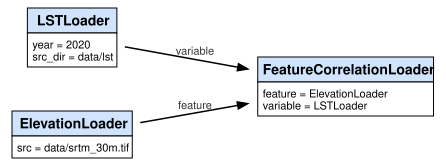

In [4]:
from affine import Affine
from pyproj import CRS
from pygeodata.graphs import plot_compact_execution_graph
from pygeodata.types import SpatialSpec

spec = SpatialSpec(
    crs=CRS.from_epsg(3035),
    transform=Affine(1000, 0, 3000000, 0, -1000, 4000000),
    shape=(100, 100),
)

loader = FeatureCorrelationLoader(
    feature=ElevationLoader(src='data/srtm_30m.tif'),
    variable=LSTLoader(year=2020),
)

graph_data = loader.get_runtime_dependency_graph(spec)

with tempfile.TemporaryDirectory() as tmp:
    path = os.path.join(tmp, 'graph_runtime.svg')
    plot_compact_execution_graph(
        graph_data=graph_data,
        root_id=loader.get_instance_hash(),
        path=path,
    )
    display(SVG(path))

Each node is labelled with its class name and parameter values. The graph is
also written to disk at
`data_processed/<state_hash>/.feature_correlation_loader.graph.pdf`
after a real `process()` call.

## Choosing what to parameterise

Not every dependency needs to be a constructor parameter. The two patterns
have different trade-offs.

**Hardcoded dependency** (call dependency detected by AST):

```python
class SlopeLoader(Data):
    def _process(self, spec):
        dem = load(ElevationLoader(), spec)
        ...
```

`SlopeLoader` always uses `ElevationLoader`. No flexibility, but the
relationship is visible in the class-level dependency graph and is captured
in the dependency tree hash. Changing `ElevationLoader` still invalidates
`SlopeLoader`.

**Constructor parameter** (data-as-parameters):

```python
@dataclass
class FeatureCorrelationLoader(Data):
    feature: Data
    variable: Data
```

Any `Data` instance can be wired in. The instance hash changes when either
input changes, whether because the input's code changed or because a different
instance was passed. Use this when the loader is genuinely generic — it should
work for any feature or variable, and the choice belongs to the caller.